Part 1: Higgs mechanism

GD converged to φ = 173.00 GeV in 73 iterations.
[100, np.float64(101.0), np.float64(102.0), np.float64(103.0), np.float64(104.0), np.float64(105.0), np.float64(106.0), np.float64(107.0), np.float64(108.0), np.float64(109.0), np.float64(110.0), np.float64(111.0), np.float64(112.0), np.float64(113.0), np.float64(114.0), np.float64(115.0), np.float64(116.0), np.float64(117.0), np.float64(118.0), np.float64(119.0), np.float64(120.0), np.float64(121.0), np.float64(122.0), np.float64(123.0), np.float64(124.0), np.float64(125.0), np.float64(126.0), np.float64(127.0), np.float64(128.0), np.float64(129.0), np.float64(130.0), np.float64(131.0), np.float64(132.0), np.float64(133.0), np.float64(134.0), np.float64(135.0), np.float64(136.0), np.float64(137.0), np.float64(138.0), np.float64(139.0), np.float64(140.0), np.float64(141.0), np.float64(142.0), np.float64(143.0), np.float64(144.0), np.float64(145.0), np.float64(146.0), np.float64(147.0), np.float64(148.0), np.float64(149.0), np.float64(150

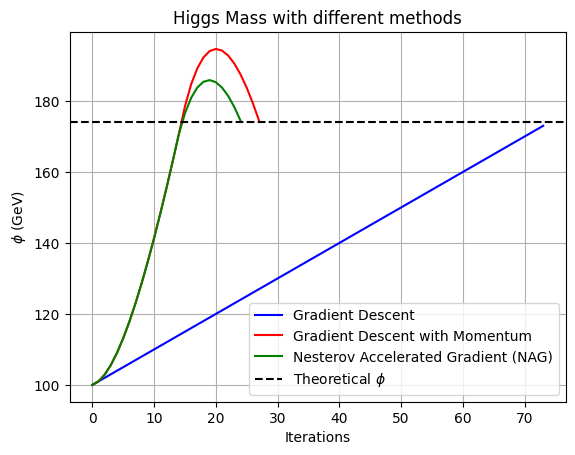

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ======== Function ==========
def gradient(phi):
    grad = - 2 * mu**2 * phi + 4 * landa * phi**3
    return np.clip(grad, -1000, 1000)

# ========= GD Function ==========
def GD(phi, iterations, mu, landa, phi_teorico, n_t, error, max_iter):
    phi_values = [phi]
    while abs(phi - phi_teorico) > error and iterations < max_iter:
        phi = phi - n_t * gradient(phi)
        
        # We prove if phi goes so far
        if abs(phi) > 1e6:
            print("Divergence detected, stopping early!")
            break

        phi_values.append(phi)
        iterations += 1

    print(f"GD converged to φ = {phi:.2f} GeV in {iterations} iterations.")
    print(phi_values)
    return phi_values

# ========== GDM Function ===========
def GDM(phi, phi_teorico, error, iterations, max_iter, gamma, v, n_t, mu, landa):
    phi_values = [phi]
    while abs(phi - phi_teorico) > error and iterations < max_iter:
        v = gamma * v + n_t * gradient(phi)  
        phi = phi - v  

        if abs(phi) > 1e6:
            print("Divergence detected, stopping early!")
            break

        phi_values.append(phi)
        iterations += 1

    print(f"Converged to φ = {phi:.2f} GeV in {iterations} iterations.")
    print(phi_values)
    return phi_values

def NAG(phi, phi_teorico, error, iterations, max_iter, gamma, v, n_t, mu, landa):
    phi_values = [phi]
    while abs(phi - phi_teorico) > error and iterations < max_iter:
        phi_new = phi + gamma * v 
        v = gamma * v - n_t * gradient(phi_new)  
        phi = phi + v  
        
        if abs(phi) > 1e6:
            print("Divergence detected, stopping early!")
            break

        phi_values.append(phi)
        iterations += 1

    print(f"Converged to φ = {phi:.2f} GeV in {iterations} iterations.")
    print(phi_values)
    return phi_values

# ======== Graphic Results =========
def show_results(GD_result, GDM_result, NAG_result):
    plt.plot(GD_result, label="Gradient Descent", color='blue')
    plt.plot(GDM_result, label="Gradient Descent with Momentum", color='red')
    plt.plot(NAG_result, label="Nesterov Accelerated Gradient (NAG)", color='green')
    plt.axhline(y=phi_teorico, color='black', linestyle='--', label="Theoretical $\phi$")
    plt.xlabel("Iterations")
    plt.ylabel("$\phi$ (GeV)")
    plt.legend()
    plt.grid(True)
    plt.title('Higgs Mass with different methods')
    plt.show()


# ======== Parameters ==========
mu = 88.39
landa = 0.129
n_t = 0.001
phi_teorico = 246 / np.sqrt(2)
error = 1
v = 0
gamma = 0.9
phi = 100

# ======== Loop parameters ==========
iterations = 0
max_iter = 10000

# ======== Methods ========
GD_result = GD(phi, iterations, mu, landa, phi_teorico, n_t, error, max_iter)
GDM_result = GDM(phi, phi_teorico, error, iterations, max_iter, gamma, v, n_t, mu, landa)
NAG_result = NAG(phi, phi_teorico, error, iterations, max_iter, gamma, v, n_t, mu, landa)

# ========= Calculate the Mass =========

mass = 2 * landa * (phi * np.sqrt(2))**2
print(f'The mass of the Higgs is: {mass}')

# ======== Results =========
show_results(GD_result, GDM_result, NAG_result)


Part 2: Two Higgs Doublet Model

GD converged to v1 = 141.42, v2 = 100.00 in 840 iterations.
GDM converged to v1 = 141.42, v2 = 100.00 in 410 iterations.
NAG converged to v1 = 141.44, v2 = 100.01 in 1000 iterations.
The mass m_H is: 200, the m_h is: 200 and the last one m_H_plus is: 100.0


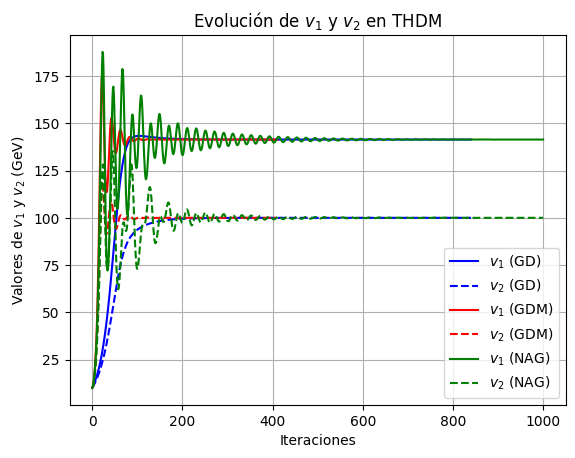

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ======== Gradient Function ==========
def gradient(v1, v2, alpha1, alpha2, beta1, beta2, beta3):
    dv1 = -2 * alpha1 * v1 + 2 * beta1 * v1**3 + 2 * beta3 * v1 * v2**2
    dv2 = -2 * alpha2 * v2 + 2 * beta2 * v2**3 + 2 * beta3 * v2 * v1**2
    return np.array([dv1, dv2])

# ========= GD Function ==========
def GD(v1, v2, alpha1, alpha2, beta1, beta2, beta3, n_t, error, max_iter):
    values = [[v1, v2]]
    iterations = 0
    while np.linalg.norm(gradient(v1, v2, alpha1, alpha2, beta1, beta2, beta3)) > error and iterations < max_iter:
        v1, v2 = np.array([v1, v2]) - n_t * gradient(v1, v2, alpha1, alpha2, beta1, beta2, beta3)
        values.append([v1, v2])
        iterations += 1
    print(f"GD converged to v1 = {v1:.2f}, v2 = {v2:.2f} in {iterations} iterations.")
    return np.array(values)

# ========== GDM Function ===========
def GDM(v1, v2, alpha1, alpha2, beta1, beta2, beta3, n_t, error, max_iter, gamma):
    values = [[v1, v2]]
    v = np.array([0.0, 0.0])
    iterations = 0
    while np.linalg.norm(gradient(v1, v2, alpha1, alpha2, beta1, beta2, beta3)) > error and iterations < max_iter:
        v = gamma * v + n_t * gradient(v1, v2, alpha1, alpha2, beta1, beta2, beta3)
        v1, v2 = np.array([v1, v2]) - v
        values.append([v1, v2])
        iterations += 1
    print(f"GDM converged to v1 = {v1:.2f}, v2 = {v2:.2f} in {iterations} iterations.")
    return np.array(values)

# ========== NAG Function ===========
def NAG(v1, v2, alpha1, alpha2, beta1, beta2, beta3, n_t, error, max_iter, gamma):
    values = [[v1, v2]]
    v = np.array([0.0, 0.0])
    iterations = 0
    while np.linalg.norm(gradient(v1, v2, alpha1, alpha2, beta1, beta2, beta3)) > error and iterations < max_iter:
        new = np.array([v1, v2]) + gamma * v
        v = gamma * v + n_t * gradient(*new, alpha1, alpha2, beta1, beta2, beta3)
        v1, v2 = np.array([v1, v2]) - v
        values.append([v1, v2])
        iterations += 1
    print(f"NAG converged to v1 = {v1:.2f}, v2 = {v2:.2f} in {iterations} iterations.")
    return np.array(values)

# ======== Plot Results ==========
def show_results(GD_result, GDM_result, NAG_result):
    plt.plot(GD_result[:, 0], label=r"$v_1$ (GD)", color='blue')
    plt.plot(GD_result[:, 1], label=r"$v_2$ (GD)", color='blue', linestyle="dashed")

    plt.plot(GDM_result[:, 0], label=r"$v_1$ (GDM)", color='red')
    plt.plot(GDM_result[:, 1], label=r"$v_2$ (GDM)", color='red', linestyle="dashed")

    plt.plot(NAG_result[:, 0], label=r"$v_1$ (NAG)", color='green')
    plt.plot(NAG_result[:, 1], label=r"$v_2$ (NAG)", color='green', linestyle="dashed")

    plt.xlabel("Iteraciones")
    plt.ylabel(r"Valores de $v_1$ y $v_2$ (GeV)")
    plt.legend()
    plt.grid(True)
    plt.title(r"Evolución de $v_1$ y $v_2$ en THDM")
    plt.show()

# ======== Parameters ==========
alpha1 = 2.5e4  # GeV^2
alpha2 = 2e4  # GeV^2
beta1 = 1
beta2 = 1
beta3 = 0.5
n_t = 1e-6
error = 1e-3
max_iter = 1000
gamma = 0.9

# Initial guesses
v1, v2 = 10, 10

# ======== Run Methods ========
GD_result = GD(v1, v2, alpha1, alpha2, beta1, beta2, beta3, n_t, error, max_iter)
GDM_result = GDM(v1, v2, alpha1, alpha2, beta1, beta2, beta3, n_t, error, max_iter, gamma)
NAG_result = NAG(v1, v2, alpha1, alpha2, beta1, beta2, beta3, n_t, error, max_iter, gamma)

# ======== Calculate the mass ========

m_H = beta1 * v1**2 + beta2 * v2**2 + abs(beta1 * v1 **2 - beta2 * v2**2)
m_h = beta1 * v1**2 + beta2 * v2**2 - abs(beta1 * v1 **2 - beta2 * v2**2)
m_H_plus = beta3 * (v1**2 + v2**2)

print(f'The mass m_H is: {m_H}, the m_h is: {m_h} and the last one m_H_plus is: {m_H_plus}')
# ======== Show Results =========
show_results(GD_result, GDM_result, NAG_result)


Part 3: Comparison with the exact results

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# ========== Functions ========
def hessian_sm_higgs(mu, lambd, phi):
    # Calculate the second derivate of the Estandard Model Higgs potential
    d2V_dphi2 = -2 * mu*2 + 12 * lambd * phi*2
    return d2V_dphi2

def hessian_thdm(alpha1, alpha2, beta1, beta2, beta3, v1, v2):
    # Calculate the Hessian Matrix of the 'Modelo de dos dobletes de higgs' potential
    d2V_dv1_2 = -2 * alpha1 + 6 * beta1 * v1*2 + 2 * beta3 * v2*2
    d2V_dv2_2 = -2 * alpha2 + 6 * beta2 * v2*2 + 2 * beta3 * v1*2
    d2V_dv1dv2 = 4 * beta3 * v1 * v2
    
    H = np.array([[d2V_dv1_2, d2V_dv1dv2],
                  [d2V_dv1dv2, d2V_dv2_2]])
    
    return H, np.linalg.det(H)

# ========== Estandard Model parameters ==========
mu = 88.39
lambd = 0.129
phi_min = mu / np.sqrt(2 * lambd)

# ============== Evaluate the Hessian to verify the minimum ==============
hessian_value = hessian_sm_higgs(mu, lambd, phi_min)
print(f"Second derivate of phi_min = {phi_min:.2f} GeV: {hessian_value:.2f}")
print("Result: Minimum found (d2V/dphi2 > 0)" if hessian_value > 0 else "Maximum found")

# ========== THDM parameters =========
alpha1 = 2.5e4  # GeV^2
alpha2 = 2.0e4  # GeV^2
beta1 = 1
beta2 = 1
beta3 = 0.5

# ========== Values that we found in GD/GDM/NAG ===========
v1_min = 140  # GeV
v2_min = 100  # GeV

# =========== Evaluate the Hessian for THDM ===========
H, det_H = hessian_thdm(alpha1, alpha2, beta1, beta2, beta3, v1_min, v2_min)
print("\n Hessian Matrix of THDM:")
print(H)
print(f"Determine Hessian: {det_H:.2f}")

# =========== Clasificate the critic point ==========
if det_H > 0 and H[0, 0] > 0:
    print("Result: Minimum found (D > 0 y d2V/dv1^2 > 0)")
elif det_H < 0:
    print("Result: Punto de silla (D < 0)")
else:
    print("Result: Maximum or indefinite")

Second derivate of phi_min = 174.02 GeV: 185.20
Result: Minimum found (d2V/dphi2 > 0)

 Hessian Matrix of THDM:
[[-48120.  28000.]
 [ 28000. -38520.]]
Determine Hessian: 1069582400.00
Result: Maximum or indefinite
